In [59]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt 

import seaborn as sns

In [60]:
df = pd.read_csv("grb_table_1743493723.txt", delimiter="\t", encoding="latin1")
df.head(2)

,GRB,Time [UT],Trigger Number,BAT RA (J2000),BAT Dec (J2000),BAT 90% Error Radius [arcmin],BAT T90 [sec],BAT Fluence (15-150 keV) [10^-7 erg/cm^2],BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2],BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],...,UVOT 90% Error Radius [arcsec],UVOT Time to First Observation [sec],UVOT Magnitude,UVOT Other Filter Magnitudes,Other Observatory Detections,Redshift,Host Galaxy,Comments,References,Burst Advocate
0,250331C,04:37:40,1299967,80.993,33.029,3,NaN,NaN,NaN,NaN,...,NaN,139,NaN,NaN,NaN,NaN,NaN,NaN,BAT: GCN 39959|XRT: GCN 39959; GCN 39960; GCN ...,Brad Cenko
1,250331B,04:19:43,1299965,71.381,43.805,3,NaN,NaN,NaN,NaN,...,NaN,317,NaN,White>19.6,NaN,NaN,NaN,NaN,BAT: GCN 39958|XRT: GCN 39958; GCN 39974|UVOT:...,Brad Cenko


<AxesSubplot:>

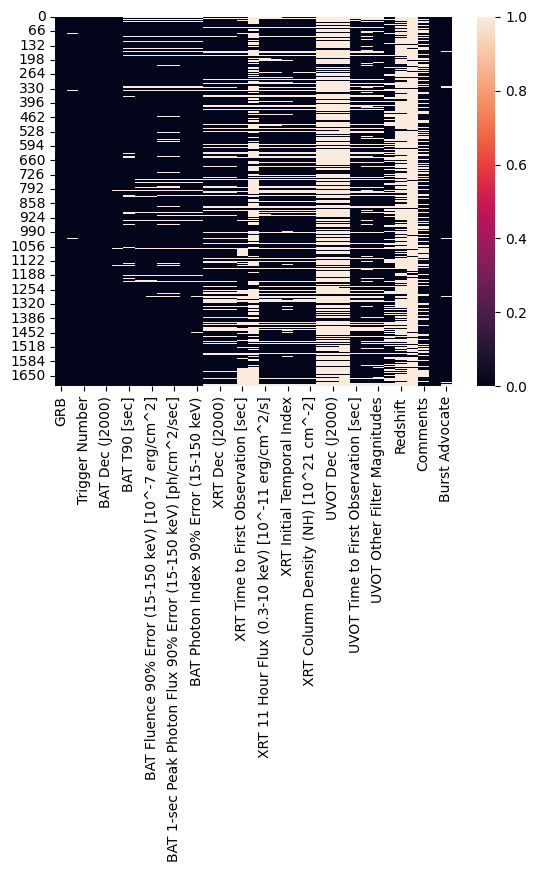

In [61]:
sns.heatmap(df.isnull())

In [62]:
len(df.columns)

35

In [63]:
df.describe()

,BAT RA (J2000),BAT Dec (J2000),BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec],BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec],XRT 90% Error Radius [arcsec],XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s],XRT Spectral Index (Gamma),XRT Column Density (NH) [10^21 cm^-2]
count,1698.000000,1698.000000,1550.000000,1546.000000,1381.000000,1351.000000,1403.000000,1403.000000
mean,180.874859,2.831421,4.141168,0.312891,1.910623,0.155418,2.063249,5.610832
std,104.353412,41.386231,12.609020,0.324408,0.985093,0.527384,1.287259,10.768963
min,0.127000,-89.029000,0.000000,0.000000,1.400000,-0.157401,0.883481,0.000000
25%,89.500500,-30.265250,0.800000,0.200000,1.400000,0.015187,1.822930,1.079406
50%,186.046500,3.576000,1.500000,0.200000,1.500000,0.045327,1.995570,2.585080
75%,270.876250,36.076250,3.400000,0.300000,2.000000,0.125899,2.171945,5.725085
max,358.751000,89.180000,331.000000,4.600000,15.000000,11.349125,47.177400,198.137000


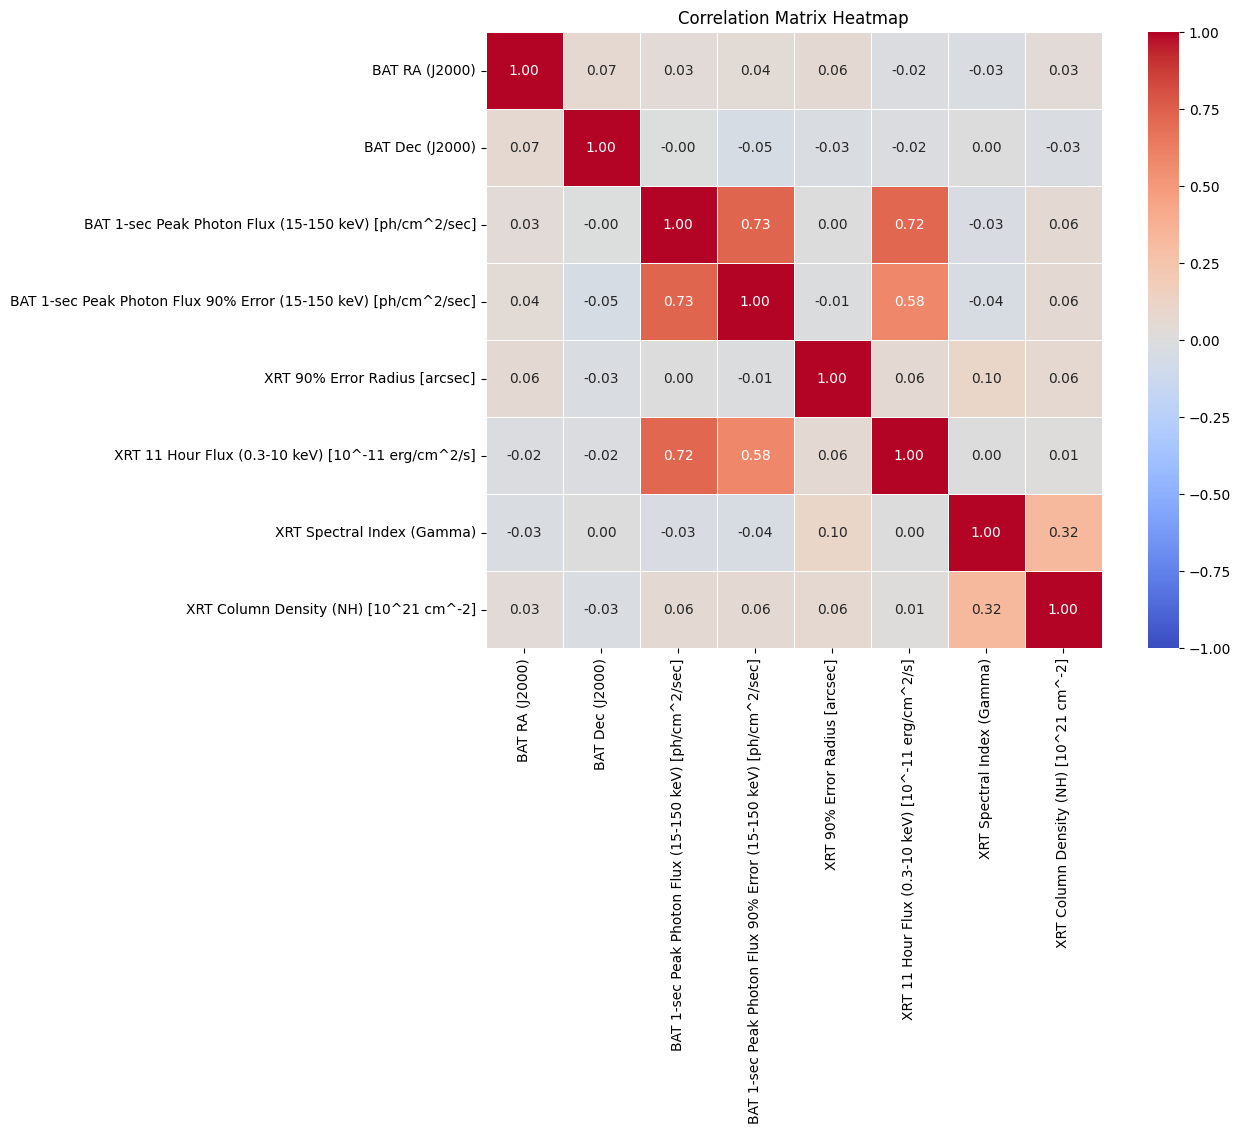

In [64]:
corr_mat = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()


In [65]:
df.drop(["XRT Early Flux (0.3-10 keV) [10^-11 erg/cm^2/s]", "UVOT RA (J2000)","UVOT Dec (J2000)","UVOT 90% Error Radius [arcsec]","Redshift","Host Galaxy", "References", "Comments", "Burst Advocate"],inplace= True, axis= 1)
df.shape


(1699, 26)

In [66]:
type(df["Time [UT]"][0])

str

In [67]:
from datetime import datetime

def time_transform(tstring):
    tstring = str(tstring)  
    
    try:
        time_obj = datetime.strptime(tstring, '%H:%M:%S.%f')  
    except ValueError:
        try:
            time_obj = datetime.strptime(tstring, '%H:%M:%S')  
        except ValueError:
            return np.nan  
    
    return int(time_obj.strftime('%H%M%S'))


df["Time [UT]"] = df["Time [UT]"].apply(time_transform)


df["Time [UT]"].head(2)

0    43740.0
1    41943.0
Name: Time [UT], dtype: float64

In [ ]:

df.drop(["GRB", "Trigger Number"], inplace= True, axis= 1)
df.shape


(1699, 24)

In [98]:
def maxchar(column):
  
    strcolumn = column.dropna().astype(str)

    return max(strcolumn)

maxchar_dict = {col: maxchar(df[col]) for col in df.columns}

print(maxchar_dict)




{'Time [UT]': '95934.0', 'BAT RA (J2000)': '99.479', 'BAT Dec (J2000)': '9.9', 'BAT 90% Error Radius [arcmin]': '~1', 'BAT T90 [sec]': '~9', 'BAT Fluence (15-150 keV) [10^-7 erg/cm^2]': '~0.9', 'BAT Fluence 90% Error (15-150 keV) [10^-7 erg/cm^2]': '~0.5', 'BAT 1-sec Peak Photon Flux (15-150 keV) [ph/cm^2/sec]': '98.7', 'BAT 1-sec Peak Photon Flux 90% Error (15-150 keV) [ph/cm^2/sec]': '4.6', 'BAT Photon Index (15-150 keV) (PL = simple power-law, CPL = cutoff power-law)': '~0.8, PL', 'BAT Photon Index 90% Error (15-150 keV)': '~0.5', 'XRT RA (J2000)': '23:55:01.62', 'XRT Dec (J2000)': '89:11:04.6', 'XRT 90% Error Radius [arcsec]': '9.3', 'XRT Time to First Observation [sec]': '~59040', 'XRT 11 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]': '9.993522e-07', 'XRT 24 Hour Flux (0.3-10 keV) [10^-11 erg/cm^2/s]': '<0.0037', 'XRT Initial Temporal Index': '~0.8', 'XRT Spectral Index (Gamma)': '9.998', 'XRT Column Density (NH) [10^21 cm^-2]': '9.99965', 'UVOT Time to First Observation [sec]': '~5

method